Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/209 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/61 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=132303033767248 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=177,855,747 params_trainable=177,855,747


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,No log,1.007884,0.600000,0.576068,0.709804,0.600000,0.201050,6.031510
2,No log,0.888346,0.700000,0.684383,0.698413,0.700000,0.169019,5.070583
3,No log,0.846037,0.700000,0.686966,0.736111,0.700000,0.155502,4.665048
4,0.870200,0.839608,0.700000,0.690541,0.759570,0.700000,0.153848,4.615447


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=3.54s tok/s=0.0 ex/s=0.00 peak_mem=3.34GiB lr=8.08e-06
[EVALUATION_PERFORMANCE] tokens=16384 time=0.05s tok/s=342160.0 ex/s=2673.12
[EVALUATION_PERFORMANCE] accuracy=0.6000 cost=$0.00 accuracy_per_$=284.17
[OPTIMIZER] epoch_start=1.0 global_step=14 wrapped=AcceleratedOptimizer base=AdamW lr=8.076923076923077e-06 id=132303033767248 hyperparams={'lr': 8.076923076923077e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 8.076923076923077e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[8.076923076923077e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=16384 time=0.11s tok/s=154924.5 ex/s=1210.35
[EVALUATION_PERFORMANCE] accuracy=0.6557 cost=$0.06 accuracy_per_$=11.20

### BERT-BASE-MULTILINGUAL-CASED EVALUATION METRICS ###
{'epoch': 4.0,
 'eval_accuracy': 0.6557377049180327,
 'eval_f1_macro': 0.6435897435897435,
 'eval_loss': 0.8132328987121582,
 'eval_mse': 0.15551362898333954,
 'eval_precision_macro': 0.6820436507936507,
 'eval_recall_macro': 0.6579365079365079,
 'eval_runtime': 0.1575,
 'eval_samples_per_second': 387.246,
 'eval_sse': 9.486331367983711,
 'eval_steps_per_second': 6.348}


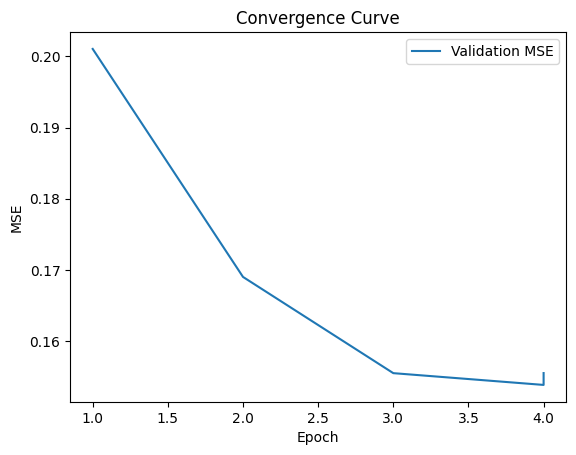

Saving the dataset (0/1 shards):   0%|          | 0/30 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/209 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/61 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mbert_context = context.setup_pipeline(MBert, require_translation = False)
    mbert_trainer = sentiment.train(mbert_context)

